## K - FOLD CROSS VALIDATION

### **What is K-Fold Cross Validation?**

**K-Fold Cross Validation** is a **model evaluation technique** used to assess how well a machine learning model generalizes to unseen data. It helps reduce **variance** in performance estimates compared to a single train-test split.

---

### **Why Use K-Fold Cross Validation?**

* It gives a **more reliable estimate** of model performance.
* Reduces risk of **overfitting** or **underfitting** due to biased train/test splits.
* Useful especially when **limited data** is available.

---

### **How It Works:**

1. The dataset is randomly divided into **K equal-sized subsets (folds)**.
2. The model is trained and evaluated **K times**:

   * In each iteration:

     * Use **K−1 folds for training**
     * Use the **remaining fold for testing**
3. **Repeat** this for all K folds so that each fold is used once as a test set.
4. The performance metrics (accuracy, precision, etc.) are **averaged** across the K iterations.

---

### **Illustration (K=5 Example):**

| Fold | Train On      | Test On |
| ---- | ------------- | ------- |
| 1    | Folds 2,3,4,5 | Fold 1  |
| 2    | Folds 1,3,4,5 | Fold 2  |
| 3    | Folds 1,2,4,5 | Fold 3  |
| 4    | Folds 1,2,3,5 | Fold 4  |
| 5    | Folds 1,2,3,4 | Fold 5  |

Then take the **average** of all 5 accuracy (or other metric) scores.

---

### **Common Variants:**

* **Stratified K-Fold**: Ensures class distribution is preserved in each fold (useful for classification tasks with imbalance).
* **Repeated K-Fold**: Repeats K-Fold multiple times with different random splits.
* **Leave-One-Out (LOO)**: Special case where `K = n_samples` (very slow, rarely used).

---

### **Key Points:**

| Term             | Meaning                                    |
| ---------------- | ------------------------------------------ |
| K                | Number of folds (commonly 5 or 10)         |
| Bias             | Lower than train/test split                |
| Variance         | Lower due to averaging across folds        |
| Use case         | Model evaluation and hyperparameter tuning |
| Computation time | Higher than a single train/test split      |

### Importing the libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Importing the dataset

In [6]:
df = pd.read_csv('../../datasets/Social_Network_Ads.csv')
print(df.sample(5))

     Age  EstimatedSalary  Purchased
310   42            70000          0
281   35            61000          0
87    28            85000          0
36    33            28000          0
252   48           134000          1


In [7]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
print(X)
print('\n')
print(y)

[[    19  19000]
 [    35  20000]
 [    26  43000]
 [    27  57000]
 [    19  76000]
 [    27  58000]
 [    27  84000]
 [    32 150000]
 [    25  33000]
 [    35  65000]
 [    26  80000]
 [    26  52000]
 [    20  86000]
 [    32  18000]
 [    18  82000]
 [    29  80000]
 [    47  25000]
 [    45  26000]
 [    46  28000]
 [    48  29000]
 [    45  22000]
 [    47  49000]
 [    48  41000]
 [    45  22000]
 [    46  23000]
 [    47  20000]
 [    49  28000]
 [    47  30000]
 [    29  43000]
 [    31  18000]
 [    31  74000]
 [    27 137000]
 [    21  16000]
 [    28  44000]
 [    27  90000]
 [    35  27000]
 [    33  28000]
 [    30  49000]
 [    26  72000]
 [    27  31000]
 [    27  17000]
 [    33  51000]
 [    35 108000]
 [    30  15000]
 [    28  84000]
 [    23  20000]
 [    25  79000]
 [    27  54000]
 [    30 135000]
 [    31  89000]
 [    24  32000]
 [    18  44000]
 [    29  83000]
 [    35  23000]
 [    27  58000]
 [    24  55000]
 [    23  48000]
 [    28  79000]
 [    22  1800

### Splitting the dataset into the Training set and Test set

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train)
print('\n')
print(X_test)
print('\n')
print(y_train)
print('\n')
print(y_test)
print('\n')

[[    27  57000]
 [    46  28000]
 [    39 134000]
 [    44  39000]
 [    57  26000]
 [    32 120000]
 [    41  52000]
 [    48  74000]
 [    26  86000]
 [    22  81000]
 [    49  86000]
 [    36  54000]
 [    40  59000]
 [    41  80000]
 [    26  16000]
 [    39  79000]
 [    59 130000]
 [    42  64000]
 [    53 143000]
 [    34 112000]
 [    57 122000]
 [    39  71000]
 [    47  25000]
 [    24  19000]
 [    36  50000]
 [    32 150000]
 [    48  29000]
 [    30 107000]
 [    60  34000]
 [    38  61000]
 [    33  31000]
 [    39  71000]
 [    55  39000]
 [    49  39000]
 [    43 112000]
 [    27  20000]
 [    26  17000]
 [    37  93000]
 [    42  54000]
 [    35  61000]
 [    29  75000]
 [    38  80000]
 [    45  26000]
 [    54 108000]
 [    46  23000]
 [    23  28000]
 [    37  75000]
 [    42  65000]
 [    35  71000]
 [    51 146000]
 [    39  96000]
 [    24  89000]
 [    58  95000]
 [    25  22000]
 [    41  59000]
 [    28  89000]
 [    42  80000]
 [    42 108000]
 [    46  9600

### Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### Training the Kernel SVM model on the Training set

In [13]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'rbf', random_state = 0)
classifier.fit(X_train, y_train)

SVC(random_state=0)

### Making the Confusion Matrix

In [15]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, recall_score, precision_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
precision = precision_score(y_test, y_pred, average='macro')
print("Precision (macro):", precision)
recall = recall_score(y_test, y_pred, average='macro')
print("Recall (macro):", recall)
f1 = f1_score(y_test, y_pred, average='macro')
print("F1 Score (macro):", f1)

Confusion Matrix:
 [[47  5]
 [ 1 27]]
Accuracy: 0.925
Precision (macro): 0.9114583333333333
Recall (macro): 0.9340659340659341
F1 Score (macro): 0.9199999999999999


### Applying the K - fold Cross Validation

In [17]:
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 90.62 %
Standard Deviation: 4.64 %


### **What is Grid Search?**

**Grid Search** is a **hyperparameter tuning** technique used to find the **best combination of parameters** for a machine learning model by **exhaustively searching** through a **predefined grid of parameter values**.

---

### **Why Use Grid Search?**

Most ML models have parameters that are **not learned from data**, but must be set manually — these are called **hyperparameters**.
Examples:

* `C`, `gamma`, `kernel` in SVM
* `n_neighbors` in KNN
* `max_depth`, `n_estimators` in Random Forest

Choosing the right values can **significantly impact model performance**. Grid Search helps automate this selection.

---

### **How Grid Search Works:**

1. You define a dictionary of parameters to test, each with a list of possible values.
2. Grid Search:

   * Trains and evaluates the model **for every possible combination** of parameters.
   * Uses **cross-validation** to evaluate each combination robustly.
3. It returns the combination that gave the **best performance** (e.g., highest accuracy or lowest error).

---

### **Example (SVM with scikit-learn):**

```python
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define model
model = SVC()

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': [0.001, 0.01, 0.1]
}

# Define grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5)

# Fit the model to training data
grid_search.fit(X_train, y_train)

# Get best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)
```

---

### **What Happens Internally?**

If `C = [0.1, 1, 10]`, `kernel = ['linear', 'rbf']`, `gamma = [0.001, 0.01, 0.1]`
Then total combinations = `3 × 2 × 3 = 18`
GridSearchCV will train and evaluate the model **18 times** (each with cross-validation).

---

### **Pros and Cons:**

| Pros                              | Cons                                   |
| --------------------------------- | -------------------------------------- |
| Simple to implement               | Computationally expensive              |
| Exhaustive — finds the best combo | Becomes slow with many hyperparameters |
| Works with cross-validation       | Can be inefficient for large grids     |

---

### **Alternatives to Grid Search:**

* **RandomizedSearchCV**: Tries a random subset of combinations, faster.
* **Bayesian Optimization**: Uses probabilistic models to find best values more intelligently.

### Applying Grid Search to find the best model and the best parameters

In [20]:
from sklearn.model_selection import GridSearchCV
parameters = [{'C' : [0.25, 0.5, 0.75, 1], 'kernel' : ['linear']},
              {'C' : [0.25, 0.5, 0.75, 1], 'kernel' : ['rbf'], 'gamma' : [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]}]
grid_search = GridSearchCV(estimator = classifier, 
                          param_grid = parameters,
                          scoring = 'accuracy',
                          cv = 10,
                          n_jobs = -1)
grid_search.fit(X_train, y_train)
best_accuracy = grid_search.best_score_
best_parameters = grid_search.best_params_
print("Best Accuracy : {:.2f} %".format(best_accuracy*100))
print("Best Parameters : ",best_parameters)

Best Accuracy : 90.94 %
Best Parameters :  {'C': 0.5, 'gamma': 0.9, 'kernel': 'rbf'}


### Visualising the Training set results

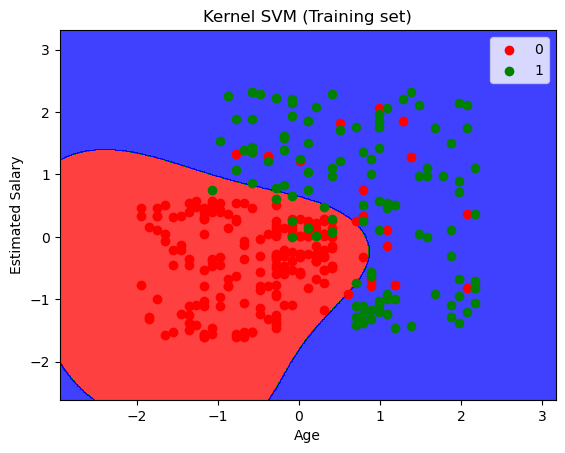

In [22]:
from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

Z = classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape)

plt.contourf(X1, X2, Z, alpha=0.75, cmap=ListedColormap(['red', 'green', 'blue']))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c=['red', 'green', 'blue'][i], label=j)

plt.title('Kernel SVM (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

### Visualising the test set results

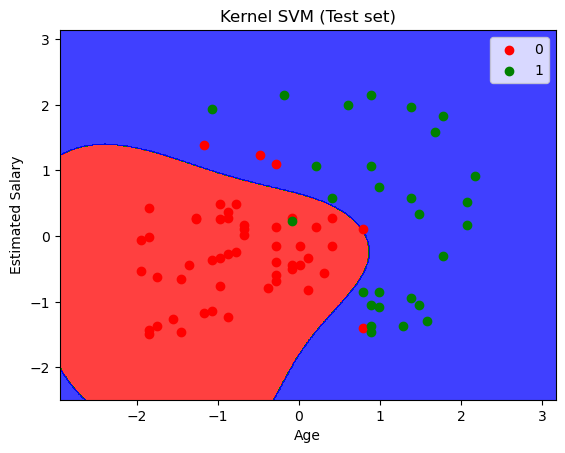

In [24]:
from matplotlib.colors import ListedColormap

X_set, y_set = X_test, y_test

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

Z = classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape)

plt.contourf(X1, X2, Z, alpha=0.75, cmap=ListedColormap(['red', 'green', 'blue']))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c=['red', 'green', 'blue'][i], label=j)

plt.title('Kernel SVM (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()